# German Language Analysis

This notebook is configured to work with German language datasets and text processing. Ensure all preprocessing, tokenization, and model steps use German language settings or resources.


# GT Keyword Extraction and Processing Workflow


In [1]:
# Configuration for German website
dataset_name = "german"
dataset_language = "german"
base_url = f"https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/{dataset_name}"
num_pages = 80

# Stemming, Compound Analysis, and Stopword Libraries for German
from nltk.stem.snowball import SnowballStemmer
import nltk
from nltk.corpus import stopwords  # Stopword library

# German compound splitting using compound-split
from compound_split.doc_split import get_best_split

# Initialize stemmer and stopwords for German
stemmer = SnowballStemmer(dataset_language)
nltk_german_stopwords = set(stopwords.words(dataset_language))


# Use get_best_split for compound splitting
def compoundsplitter(word):
    return get_best_split(word)


# Tag rating set (updated values for German)
tag_rating_set = {
    "title": 41.8507,
    "h1": 26.3131,
    "URL": 18.9299,
    "h2": 12.9877,
    "a": 9.8007,
    "html": 9.7465,
    "body": 9.2142,
    "li": 8.6534,
    "div": 8.6341,
    "ul": 8.4722,
    "p": 7.7600,
    "span": 7.6541,
    "nav": 6.4883,
    "header": 6.4320,
}

In [2]:
import re


def process_keywords(keywords):
    """Apply cleaning, German compound splitting (compound-split), stemming, and stopword filtering to a list of keywords. Returns a processed list of useful words."""
    processed = []
    for word in keywords:
        # Clean word: keep only alphabetic characters (including German letters)
        cleaned_word = re.sub(r"[^a-zA-ZäöüßÄÖÜẞ]", "", word)
        if not cleaned_word:
            continue
        # Compound splitting (German, using compound-split)
        compound_parts = [cleaned_word]
        try:
            split_result = compoundsplitter(cleaned_word)
            if split_result and isinstance(split_result, list):
                # split_result is a list of parts
                compound_parts.extend(
                    [
                        part.lower()
                        for part in split_result
                        if part.lower() != cleaned_word.lower()
                    ]
                )
        except Exception:
            pass
        # Clean all compound parts
        cleaned_parts = [
            re.sub(r"[^a-zA-ZäöüßÄÖÜẞ]", "", part) for part in compound_parts
        ]
        # Remove empty strings after cleaning
        cleaned_parts = [part for part in cleaned_parts if part]
        # Stem all parts
        stemmed_parts = [stemmer.stem(part) for part in cleaned_parts]
        # Filter stopwords
        filtered = [part for part in stemmed_parts if part not in nltk_german_stopwords]
        processed.extend(filtered)
    # Return unique processed keywords (useful words only)
    return list(set(processed))

In [3]:
from bs4 import BeautifulSoup


def extract_and_process_keywords_from_tag(html_text, tag_name):
    """Extracts keywords from the content inside the specified tag in the given HTML text, processes them using process_keywords, and returns a dictionary with keyword frequencies."""
    soup = BeautifulSoup(html_text, "html.parser")
    elements = soup.find_all(tag_name)
    raw_keywords = []
    for elem in elements:
        text = elem.get_text(separator=" ")
        raw_keywords.extend(text.split())
    processed = process_keywords(raw_keywords)
    freq = {}
    for kw in processed:
        freq[kw] = freq.get(kw, 0) + 1
    return freq

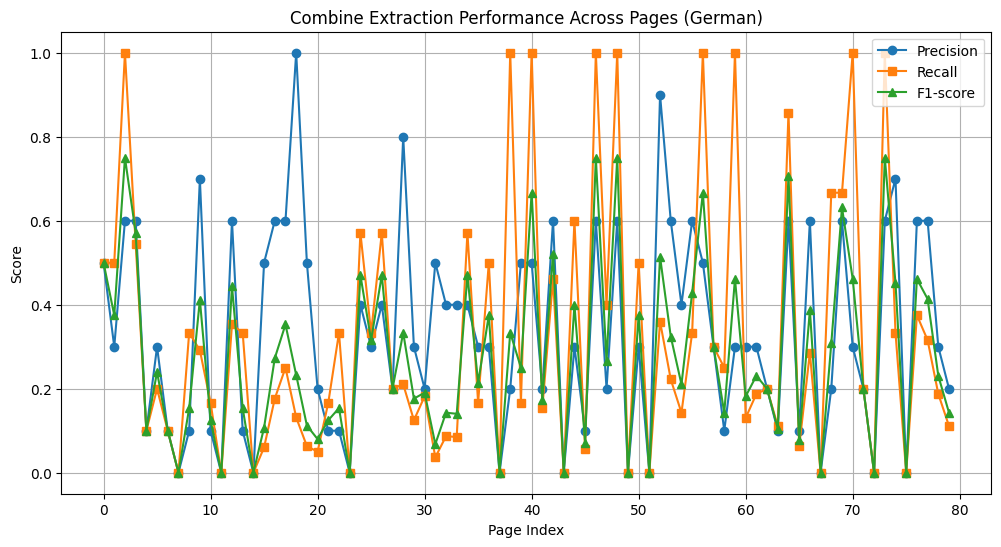


Average Precision: 0.3363
Average Recall: 0.3241
Average F1-score: 0.2810


In [4]:
# 5. Aggregate and Print URL Ratings Across All Pages (as a pseudo-tag for sorting)
from urllib.parse import urlparse, unquote
from collections import defaultdict
import urllib.request
import matplotlib.pyplot as plt

frequency_weight = 10

# Store metrics for all pages
dataset_precisions = []
dataset_recalls = []
dataset_f1s = []

for i in range(num_pages):
    gt_url = f"{base_url}/{i}/GT.txt"
    html_url = f"{base_url}/{i}/HTML.txt"
    url_file_url = f"{base_url}/{i}/URL.txt"
    processed_gt_keywords = []
    extracting_keywords = {}
    headers = {"User-Agent": "Mozilla/5.0 (compatible; Copilot/1.0)"}
    gt_req = urllib.request.Request(gt_url, headers=headers)
    html_req = urllib.request.Request(html_url, headers=headers)
    url_req = urllib.request.Request(url_file_url, headers=headers)
    gt_length = -1
    try:
        with urllib.request.urlopen(gt_req, timeout=5) as response:
            gt_text = response.read().decode("utf-8-sig").strip()
            gt_keywords = gt_text.split()
            gt_length = len(gt_keywords)
            processed_gt_keywords = list(set(process_keywords(gt_keywords)))
    except Exception as e:
        continue
    # HTML tag ratings
    try:
        with urllib.request.urlopen(html_req, timeout=5) as html_response:
            html_text = html_response.read().decode("utf-8-sig").strip()

            for tag, rating in tag_rating_set.items():
                result = extract_and_process_keywords_from_tag(html_text, tag)
                for kw, freq in result.items():
                    value = rating + freq * frequency_weight
                    if kw in extracting_keywords:
                        extracting_keywords[kw] += value
                    else:
                        extracting_keywords[kw] = value
    except Exception as e:
        continue
    # URL rating as a pseudo-tag
    try:
        with urllib.request.urlopen(url_req, timeout=5) as url_response:
            real_url = url_response.read().decode("utf-8-sig").strip()
            parsed_url = urlparse(real_url)
            normalized_path = unquote(parsed_url.path.lower())
            url_tokens = re.findall(r"[a-zåäöA-ZÅÄÖ0-9]+", normalized_path)
            processed_url_keywords = process_keywords(url_tokens)
            # Use the same scoring pattern as tags, with 'URL' rating
            url_rating = tag_rating_set.get("URL", 0)
            for kw in processed_url_keywords:
                value = url_rating  # treat each URL keyword as freq=1
                if kw in extracting_keywords:
                    extracting_keywords[kw] += value
                else:
                    extracting_keywords[kw] = value
    except Exception as e:
        continue
    # Calculate Precision, Recall, and F1-score
    top_10 = sorted(extracting_keywords.items(), key=lambda x: x[1], reverse=True)[:10]
    extracted_keywords = set([kw for kw, _ in top_10])
    gt_keywords_set = set(processed_gt_keywords)

    # Calculate metrics
    true_positives = len(extracted_keywords & gt_keywords_set)
    precision = (
        true_positives / len(extracted_keywords) if len(extracted_keywords) > 0 else 0
    )
    # recall = true_positives / len(gt_keywords_set) if len(gt_keywords_set) > 0 else 0
    recall = true_positives / gt_length if gt_length > 0 else 0
    if recall > 1:
        recall = 1
    f1_score = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    dataset_precisions.append(precision)
    dataset_recalls.append(recall)
    dataset_f1s.append(f1_score)

    # print(f"Page {i}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1_score:.4f}")

# Visualize and compare performance
plt.figure(figsize=(12, 6))
plt.plot(dataset_precisions, label="Precision", marker="o")
plt.plot(dataset_recalls, label="Recall", marker="s")
plt.plot(dataset_f1s, label="F1-score", marker="^")
plt.xlabel("Page Index")
plt.ylabel("Score")
plt.title("Combine Extraction Performance Across Pages (German)")
plt.legend()
plt.grid(True)
plt.show()

# Print average metrics
print(f"\nAverage Precision: {sum(dataset_precisions)/len(dataset_precisions):.4f}")
print(f"Average Recall: {sum(dataset_recalls)/len(dataset_recalls):.4f}")
print(f"Average F1-score: {sum(dataset_f1s)/len(dataset_f1s):.4f}")